In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

# Custom 4x4 map:
# S = Start, G = Goal, H = Hole, F = Frozen surface
# Start state = 5, Goal state = 10

custom_map = [
    "FFFF",
    "FSHF",
    "FHGF",
    "FFFF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=False
)

n_states = env.observation_space.n
n_actions = env.action_space.n

START_STATE = 5
GOAL_STATE = 10

print("Number of states:", n_states)
print("Number of actions:", n_actions)
print("Starting state:", START_STATE)
print("Goal state:", GOAL_STATE)

assert START_STATE != 0, "Start state must not be 0"
assert GOAL_STATE != n_states - 1, "Goal state must not be the last state"


Number of states: 16
Number of actions: 4
Starting state: 5
Goal state: 10


In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995


In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))

# Store reward obtained in each episode
episode_rewards = []

# Store epsilon value for each episode
epsilon_history = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """Select an action using an epsilon-greedy policy."""

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    max_actions = np.flatnonzero(
        Q[state] == np.max(Q[state])
    )

    # Randomly choose among equally good actions in case of a tie
    return np.random.choice(max_actions)


In [5]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

for episode in range(num_episodes):

    # Reset environment and force the required starting state.
    # FrozenLake reset starts from the S tile in custom_map, which is state 5.
    state, info = env.reset()
    assert state == START_STATE

    # Record the epsilon value used in this episode
    epsilon_history.append(epsilon)

    # Select initial action using the current epsilon
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Select next action using the current epsilon
        if terminated or truncated:
            next_action = None
        else:
            next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA target
        if terminated or truncated:
            td_target = reward
        else:
            td_target = reward + gamma * Q[next_state, next_action]

        # SARSA update
        Q[state, action] += alpha * (
            td_target - Q[state, action]
        )

        total_reward += reward

        if terminated or truncated:
            break

        # Move to next state-action pair
        state = next_state
        action = next_action

    episode_rewards.append(total_reward)

    # Variable epsilon: gradually reduce exploration
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training completed.")
print("Initial epsilon:", epsilon_history[0])
print("Final epsilon:", epsilon)


Training completed.
Initial epsilon: 1.0
Final epsilon: 0.05


In [6]:
# -------------------------------------------------
# Derive State-Value Function and Learned Policy
# -------------------------------------------------

# V(s) = max_a Q(s,a)
state_values = np.max(Q, axis=1)

# Learned policy: best action for every state
learned_policy = np.argmax(Q, axis=1)


In [7]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [8]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.692 0.884 0.723 0.714]
 [0.76  0.714 0.354 0.583]
 [0.607 0.    0.027 0.173]
 [0.002 0.123 0.007 0.004]
 [0.817 0.933 0.659 0.804]
 [0.891 0.    0.    0.758]
 [0.    0.    0.    0.   ]
 [0.    0.508 0.033 0.004]
 [0.91  0.969 0.    0.871]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.994 0.396 0.508 0.104]
 [0.904 0.891 0.976 0.814]
 [0.949 0.976 0.989 0.   ]
 [0.976 0.987 0.974 1.   ]
 [0.99  0.789 0.833 0.74 ]]

Estimated State-Value Function:
[[0.884 0.76  0.607 0.123]
 [0.933 0.891 0.    0.508]
 [0.969 0.    0.    0.994]
 [0.976 0.989 1.    0.99 ]]

Learned Policy:
[['D' 'L' 'L' 'D']
 ['D' 'L' 'L' 'D']
 ['D' 'L' 'L' 'L']
 ['R' 'R' 'U' 'L']]

Average reward over last 1000 episodes: 0.942


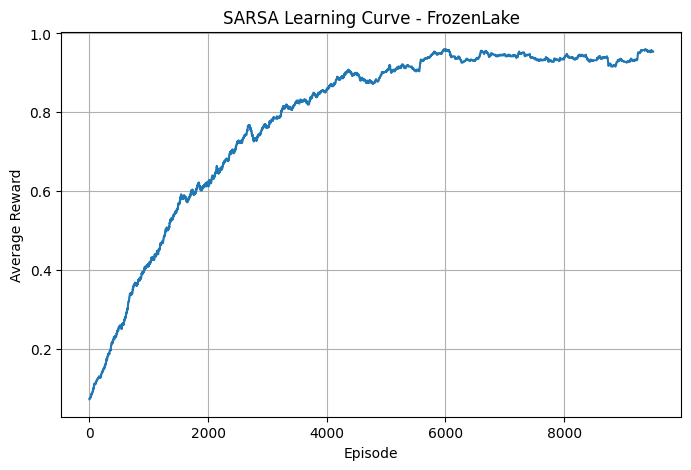

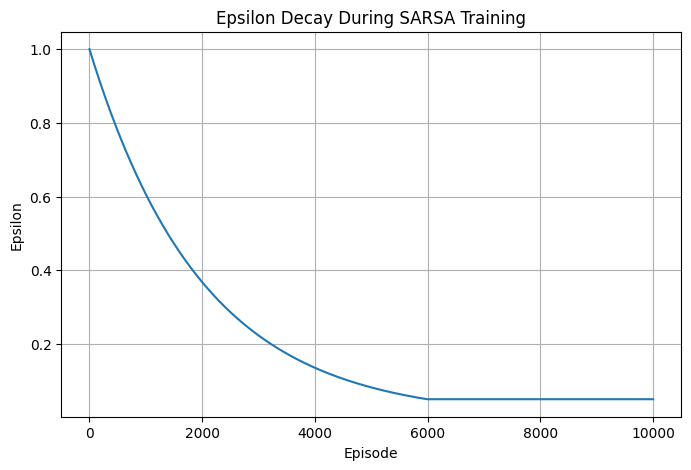

In [9]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

# -------------------------------------------------
# Plot Variable Epsilon
# -------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(epsilon_history)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay During SARSA Training")
plt.grid(True)
plt.show()

env.close()
